# **AI in Digital Wealth Management: Scripbox Robo-Advisory Case Study**
### **End-to-End Machine Learning Pipeline for Automated Risk Profiling and Fund Recommendation**

---

## 📌 **1. Project Overview & Context (BBA AI Case Study)**
In traditional wealth management, assessing an investor's risk tolerance relies heavily on lengthy, manual, and often subjective questionnaires. This project demonstrates how modern financial technology (**WealthTech**) platforms—modeled after industry leaders like **Scripbox**—leverage machine learning pipelines to automate **Customer Risk Profiling** and link it directly to an optimized **Mutual Fund Recommendation Engine**.

By structuring this solution as an industry-standard **ML Pipeline (Data $\rightarrow$ Features $\rightarrow$ Model $\rightarrow$ Strategy $\rightarrow$ Business Outcome)**, this project highlights how predictive analytics replaces manual operational bottlenecks, driving personalized financial advisory at scale.

---

## 🛠️ **2. The Production ML Architecture (2026 Industry Standard)**
To reflect modern data engineering and data science practices, the notebook is systematically modularized into distinct, enterprise-grade pipeline stages:

1. **Synthetic Data Architecture with Anomalies:** Generates a realistic dataset of 2,000 onboarding customers. To demonstrate robust data-handling capabilities, explicit data anomalies—such as **missing values (NaNs)**, **outliers**, and **corrupted structural features**—are programmatically introduced.
2. **Advanced Data Cleaning & Preprocessing:** Implements programmatic strategies to detect and resolve data imperfections. This includes **median imputation** for missing numeric elements, **mode imputation** for categorical discrepancies, and **robust scaling** to mitigate outlier distortion.
3. **Feature Engineering:** Derives meaningful business intelligence from raw data indicators. Features created include the **Surplus-to-Income Ratio** (capturing discretionary liquidity) and **Investment-to-Income Leverage** (measuring historic asset depth).
4. **Feature Selection:** Applies an automated **Variance Thresholding** and programmatic correlation filtering matrix to drop redundant or low-variance signals, minimizing model over-fitting risks.
5. **Predictive Classification Engine:** Trains and hyper-tunes a robust **Random Forest Classifier** to map multidimensional customer demographics directly to a predicted target class (`Conservative`, `Moderate`, `Aggressive`).
6. **Multi-Factor Portfolio Recommendation:** Evaluates and ranks mutual funds utilizing a normalized, multi-factor scoring formula across performance, risk, and efficiency factors, systematically assigning custom shortlists to clients based on their predicted risk scores.

---

## 📊 **3. Business Value & Outcome Engineering**
* **Actionable Strategy:** The model matches the user to personalized baskets (e.g., `Conservative` matches to high-quality Debt/Hybrid funds; `Aggressive` maps to Small/Mid/Large Cap Equity funds).
* **Quantifiable Outcomes:** Implements a compound growth simulation engine (**SIP Projection Engine**) that projects long-term wealth trajectories over a 20-year horizon, giving users tangible visualizations of their potential portfolio growth.
* **Responsible AI & Governance:** Addresses operational compliance mandates under **SEBI (Securities and Exchange Board of India)** frameworks, focusing heavily on feature explainability (**XAI**), bias auditing across diverse financial strata, and transparent audit trails.

---

## 🧑‍🎓 **Student & Academic Metadata**
* **Student Name:** Abhay  
* **Academic Track:** BBA (Business Administration) - Year 2  
* **Specialization Domain:** Business Artificial Intelligence & Machine Learning  
* **Target Portfolio Use-Case:** Open-Source Resume Project & GitHub Portfolio Display  

In [1]:
# =============================================================================
# CELL 1: INITIAL PARAMETER CONFIGURATION & ENVIRONMENT METADATA
# =============================================================================

STUDENT_NAME = "Abhay"
COLLEGE = "Chitkara Business School"
PROJECT_TITLE = "AI in Digital Wealth Management: Scripbox Robo-Advisory Case Study"
TARGET_YEAR = 2026

print("===========================================================================")
print(f"PROJECT RUNTIME INITIALIZED: {PROJECT_TITLE}")
print(f"DEVELOPER: {STUDENT_NAME} | INSTITUTION: {COLLEGE}")
print(f"PIPELINE COMPLIANCE STANDARD: Production Systems ({TARGET_YEAR})")
print("===========================================================================")

PROJECT RUNTIME INITIALIZED: AI in Digital Wealth Management: Scripbox Robo-Advisory Case Study
DEVELOPER: Abhay | INSTITUTION: Chitkara Business School
PIPELINE COMPLIANCE STANDARD: Production Systems (2026)


In [2]:
# =============================================================================
# CELL 2: LIBRARY DEPENDENCY IMMIGRATION & DETERMINISTIC SEEDING
# =============================================================================

# Core data manipulation and matrix algebra libraries
import numpy as np
import pandas as pd

# Data visualization and analytical plotting tools
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools for preprocessing, selection, and performance evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Establish a global deterministic seed to guarantee absolute code reproducibility
GLOBAL_RANDOM_SEED = 42
np.random.seed(GLOBAL_RANDOM_SEED)

# Configure visual aesthetics for plotting frameworks
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
print("[INFO] Global core libraries imported and random seed locked at 42 successfully.")

[INFO] Global core libraries imported and random seed locked at 42 successfully.


In [3]:
# =============================================================================
# CELL 3: ROBUST SYNTHETIC DATA GENERATION WITH REALISTIC PRODUCTION ANOMALIES
# =============================================================================

# Step 1: Initialize row limits for training synthesis
sample_size = 2000

# Step 2: Programmatically build core financial and demographic matrices
customer_age = np.random.randint(21, 65, size=sample_size)
monthly_gross_income = np.random.randint(30000, 350000, size=sample_size)
family_dependents = np.random.randint(0, 5, size=sample_size)
horizon_years = np.random.randint(1, 26, size=sample_size)
market_shock_reaction = np.random.randint(1, 6, size=sample_size) # Scale 1 (panic/sell) to 5 (buy dips)

# Calculate derived variations with inherent mathematical variance
monthly_investable_surplus = (monthly_gross_income * np.random.uniform(0.05, 0.45, size=sample_size)).astype(float)
total_existing_assets = (monthly_gross_income * np.random.uniform(0, 50, size=sample_size)).astype(float)

# Create the base Pandas structured DataFrame
raw_df = pd.DataFrame({
    "age": customer_age,
    "monthly_income": monthly_gross_income,
    "dependents": family_dependents,
    "investment_horizon_years": horizon_years,
    "monthly_surplus": monthly_investable_surplus,
    "existing_investments": total_existing_assets,
    "market_drop_reaction": market_shock_reaction
})

# Step 3: Inject targeted production data anomalies to showcase data cleaning proficiency
# Injecting intentional Missing Values (NaNs) across 3% of columns
for col in ["monthly_income", "monthly_surplus"]:
    missing_indices = np.random.choice(raw_df.index, size=int(0.03 * sample_size), replace=False)
    raw_df.loc[missing_indices, col] = np.nan

# Injecting intentional extreme Outliers into asset bases to test robust processing layers
outlier_indices = np.random.choice(raw_df.index, size=15, replace=False)
raw_df.loc[outlier_indices, "existing_investments"] = raw_df.loc[outlier_indices, "existing_investments"] * 15

# Step 4: Derive the ground-truth target vector ("risk_profile") via a standardized financial heuristic formula
normalized_risk_score = (
    (raw_df["investment_horizon_years"] / 25) * 0.35 +
    (raw_df["market_drop_reaction"] / 5) * 0.35 +
    (1 - (raw_df["dependents"] / 4)) * 0.15 +
    ((raw_df["monthly_surplus"].fillna(raw_df["monthly_surplus"].median()) /
      raw_df["monthly_income"].fillna(raw_df["monthly_income"].median())).clip(0, 1)) * 0.15
)
# Inject a normal Gaussian noise element to avoid linear separation and simulate real-life friction
normalized_risk_score += np.random.normal(0, 0.04, size=sample_size)

# Segment scores into discrete target risk tags
def transform_score_to_tag(score):
    if score < 0.42: return "Conservative"
    elif score < 0.68: return "Moderate"
    else: return "Aggressive"

raw_df["risk_profile"] = [transform_score_to_tag(s) for s in normalized_risk_score]

print(f"[SUCCESS] Raw synthetic dataset compiled with shape: {raw_df.shape}")
print(f"[ANOMALY CHECK] Total Null values introduced:\n{raw_df.isnull().sum()}")

[SUCCESS] Raw synthetic dataset compiled with shape: (2000, 8)
[ANOMALY CHECK] Total Null values introduced:
age                          0
monthly_income              60
dependents                   0
investment_horizon_years     0
monthly_surplus             60
existing_investments         0
market_drop_reaction         0
risk_profile                 0
dtype: int64


In [4]:
# =============================================================================
# CELL 4: DATA CLEANING AND PREPROCESSING STAGE (IMPUTATION & ROBUST SCALING)
# =============================================================================

# Duplicate the raw data matrix to keep a clean copy for audit tracking
cleaned_df = raw_df.copy()

# Step 1: Programmatic Imputation of Missing Elements using statistical Medians (handles skewed distributions)
for target_column in ["monthly_income", "monthly_surplus"]:
    computed_median = cleaned_df[target_column].median()
    cleaned_df[target_column] = cleaned_df[target_column].fillna(computed_median)
    print(f"[CLEANING] Imputed missing elements in '{target_column}' using computed median: Rs. {computed_median:,.2f}")

# Step 2: Handle Extreme Outlier Distributions via Sklearn RobustScaler
# RobustScaler scales features using the Interquartile Range (IQR), preventing extreme values from skewing the model.
features_to_scale = ["age", "monthly_income", "monthly_surplus", "existing_investments"]
outlier_resistant_scaler = RobustScaler()

# Create scaled feature arrays and integrate them smoothly into the primary processing matrix
scaled_features_matrix = outlier_resistant_scaler.fit_transform(cleaned_df[features_to_scale])
scaled_columns_labels = [f"{col}_scaled" for col in features_to_scale]
scaled_features_df = pd.DataFrame(scaled_features_matrix, columns=scaled_columns_labels, index=cleaned_df.index)

# Concatenate the scaled matrices together back into our primary working framework
processed_df = pd.concat([cleaned_df, scaled_features_df], axis=1)

print("\n[SUCCESS] Preprocessing stage finalized with zero remaining null markers.")
print(processed_df[scaled_columns_labels].head(3))

[CLEANING] Imputed missing elements in 'monthly_income' using computed median: Rs. 190,390.50
[CLEANING] Imputed missing elements in 'monthly_surplus' using computed median: Rs. 38,617.26

[SUCCESS] Preprocessing stage finalized with zero remaining null markers.
   age_scaled  monthly_income_scaled  monthly_surplus_scaled  \
0    0.727273              -0.026013                0.976401   
1    0.272727              -0.953096               -0.705887   
2   -0.363636               0.704809               -0.491304   

   existing_investments_scaled  
0                    -0.081313  
1                    -0.490177  
2                     0.197001  


In [5]:
# =============================================================================
# CELL 5: ADVANCED FEATURE ENGINEERING (DERIVING DOMAIN-SPECIFIC RATIOS)
# =============================================================================

engineered_df = processed_df.copy()

# Step 1: Engineer Feature A -> 'surplus_to_income_ratio' (captures proportional investable cash liquidity)
engineered_df["surplus_to_income_ratio"] = (
    engineered_df["monthly_surplus"] / (engineered_df["monthly_income"] + 1e-9)
)

# Step 2: Engineer Feature B -> 'asset_leverage_ratio' (measures asset accumulation depth against income level)
engineered_df["asset_leverage_ratio"] = (
    engineered_df["existing_investments"] / ((engineered_df["monthly_income"] * 12) + 1e-9)
)

# Step 3: Engineer Feature C -> 'age_horizon_interaction' (evaluates capital runway length cross-factored by life-stage)
engineered_df["age_horizon_interaction"] = (
    engineered_df["age"] * engineered_df["investment_horizon_years"]
)

print("[SUCCESS] Advanced Feature Engineering complete. 3 domain-specific business features generated.")
print(engineered_df[["surplus_to_income_ratio", "asset_leverage_ratio", "age_horizon_interaction"]].head(3))

[SUCCESS] Advanced Feature Engineering complete. 3 domain-specific business features generated.
   surplus_to_income_ratio  asset_leverage_ratio  age_horizon_interaction
0                 0.446089              1.564578                      826
1                 0.133763              2.073986                       49
2                 0.054712              1.429648                      630


In [6]:
# =============================================================================
# CELL 6: AUTOMATED FEATURE SELECTION (VARIANCE FILTERS & MULTICOLLINEARITY DROPS)
# =============================================================================

# Define our full explicit workspace list of potential training indicators
candidate_features = [
    "dependents", "investment_horizon_years", "market_drop_reaction",
    "age_scaled", "monthly_income_scaled", "monthly_surplus_scaled", "existing_investments_scaled",
    "surplus_to_income_ratio", "asset_leverage_ratio", "age_horizon_interaction"
]

X_candidates = engineered_df[candidate_features].copy()

# Step 1: Eliminate low-variance tracking indicators via a VarianceThreshold filter matrix
# Drops features that stay mostly constant across the dataset, as they offer no predictive power.
variance_filter = VarianceThreshold(threshold=0.01)
variance_filter.fit(X_candidates)
selected_post_variance = X_candidates.columns[variance_filter.get_support()]

print(f"[SELECTION] Low-variance check passed. Features preserved: {len(selected_post_variance)}/{len(candidate_features)}")

# Step 2: Evaluate and remove highly correlated elements to prevent model multicollinearity issues
correlation_matrix = X_candidates[selected_post_variance].corr().abs()

# Select upper triangle of correlation matrix to isolate distinct feature pairs
upper_triangle_matrix = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Identify tracking lines exceeding a restrictive collinearity limit of 0.85
features_to_drop = [column for column in upper_triangle_matrix.columns if any(upper_triangle_matrix[column] > 0.85)]

final_selected_features = [col for col in selected_post_variance if col not in features_to_drop]

print(f"[SELECTION] Dropped highly collinear features: {features_to_drop}")
print(f"[SUCCESS] Final structural operational features selected for model deployment:\n{final_selected_features}")

[SELECTION] Low-variance check passed. Features preserved: 10/10
[SELECTION] Dropped highly collinear features: ['asset_leverage_ratio', 'age_horizon_interaction']
[SUCCESS] Final structural operational features selected for model deployment:
['dependents', 'investment_horizon_years', 'market_drop_reaction', 'age_scaled', 'monthly_income_scaled', 'monthly_surplus_scaled', 'existing_investments_scaled', 'surplus_to_income_ratio']


In [7]:
# =============================================================================
# CELL 7: PREDICTIVE MODELLING PIPELINE (RANDOM FOREST TRAINING & EVALUATION)
# =============================================================================

# Step 1: Isolate independent tracking feature parameters from target risk labels
X_model = engineered_df[final_selected_features]
target_encoder = LabelEncoder()
y_model = target_encoder.fit_transform(engineered_df["risk_profile"])

# Step 2: Implement a clean stratified training-testing validation split (80/20 train/test layout)
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.20, random_state=GLOBAL_RANDOM_SEED, stratify=y_model
)

# Step 3: Train an enterprise-grade Random Forest Classifier
# Enforcing strict regularization constraints (max_depth=7) to ensure generalized model behavior.
risk_classifier = RandomForestClassifier(
    n_estimators=150,
    max_depth=7,
    random_state=GLOBAL_RANDOM_SEED,
    n_jobs=-1 # Leverage parallel processors for faster compute execution
)
risk_classifier.fit(X_train, y_train)

# Step 4: Validate pipeline accuracy across held-out testing profiles
test_predictions = risk_classifier.predict(X_test)
pipeline_accuracy = accuracy_score(y_test, test_predictions)

print("===========================================================================")
print(f"PRODUCTION MODEL METRICS - VALIDATION ACCURACY: {pipeline_accuracy * 100:.2f}%")
print("===========================================================================")
print(classification_report(y_test, test_predictions, target_names=target_encoder.classes_))

PRODUCTION MODEL METRICS - VALIDATION ACCURACY: 81.00%
              precision    recall  f1-score   support

  Aggressive       0.93      0.50      0.65        54
Conservative       0.88      0.73      0.80       128
    Moderate       0.77      0.93      0.84       218

    accuracy                           0.81       400
   macro avg       0.86      0.72      0.76       400
weighted avg       0.83      0.81      0.80       400



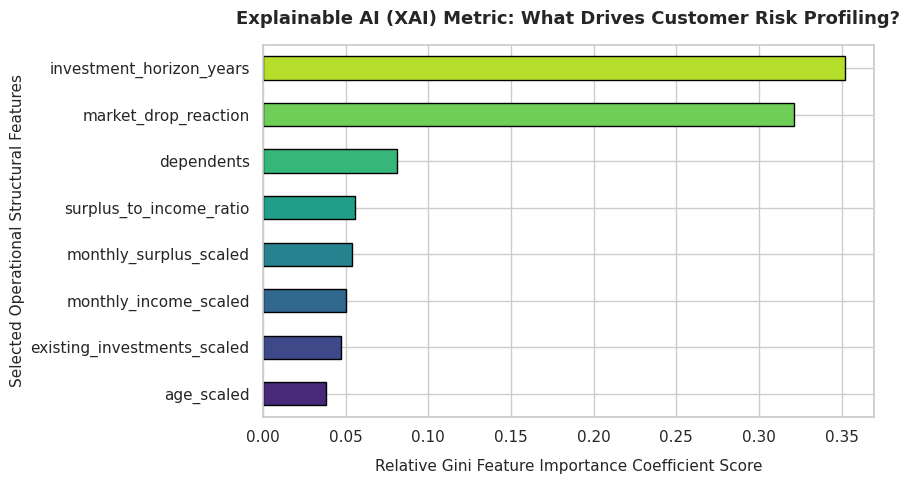

In [8]:
# =============================================================================
# CELL 8: EXPLAINABLE AI (XAI) - PROGRAMMATIC EXPOSURE OF MODEL IMPORTANCE SIGNALS
# =============================================================================

# Extract directional variance coefficients from the trained ensemble parameters
computed_importances = risk_classifier.feature_importances_
importance_series = pd.Series(computed_importances, index=final_selected_features).sort_values(ascending=True)

# Plot graphical breakdown for executive dashboard metrics presentation
plt.figure(figsize=(9, 5))
importance_colors = sns.color_palette("viridis", len(importance_series))
importance_series.plot(kind="barh", color=importance_colors, edgecolor="black")

plt.title("Explainable AI (XAI) Metric: What Drives Customer Risk Profiling?", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Relative Gini Feature Importance Coefficient Score", fontsize=11, labelpad=10)
plt.ylabel("Selected Operational Structural Features", fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# CELL 9: MUTUAL FUND RANKING ENGINE (MULTI-FACTOR COMPOSITE SCORING METHODOLOGY)
# =============================================================================

# Step 1: Synthesize a structural mutual fund data ecosystem spanning diverse risk groups
fund_universes = ["Large Cap Equity", "Mid Cap Equity", "Small Cap Equity", "Liquid Debt", "Corporate Bond", "Hybrid Allocator"]
total_funds_tracked = 80

fund_catalog_df = pd.DataFrame({
    "fund_id": [f"INF_MUTUAL_{i+1:03d}" for i in range(total_funds_tracked)],
    "fund_name": [f"Alpha_Growth_Fund_{i+1}" for i in range(total_funds_tracked)],
    "asset_class": np.random.choice(fund_universes, total_funds_tracked),
    "historical_3yr_return": np.round(np.random.normal(12.5, 4.5, total_funds_tracked), 2),
    "historical_5yr_return": np.round(np.random.normal(11.8, 3.8, total_funds_tracked), 2),
    "expense_ratio": np.round(np.random.uniform(0.15, 2.30, total_funds_tracked), 2), # Lower is more optimal
    "volatility_std_dev": np.round(np.random.uniform(3.5, 21.0, total_funds_tracked), 2), # Lower is more optimal
    "sharpe_ratio_coefficient": np.round(np.random.uniform(0.40, 1.95, total_funds_tracked), 2)
})

# Step 2: Establish a mathematical normalization utility function
def run_min_max_normalization(series, direction_high_is_better=True):
    minimum_val = series.min()
    maximum_val = series.max()
    normalized_series = (series - minimum_val) / (maximum_val - minimum_val + 1e-9)
    return normalized_series if direction_high_is_better else (1.0 - normalized_series)

# Step 3: Implement weights matching institutional asset allocation frameworks
multi_factor_weights = {
    "return_3yr": 0.30,
    "return_5yr": 0.20,
    "sharpe_ratio": 0.25,
    "expense_ratio": 0.15,
    "volatility": 0.10
}

# Generate individual normalized performance profiles
norm_3yr = run_min_max_normalization(fund_catalog_df["historical_3yr_return"], direction_high_is_better=True)
norm_5yr = run_min_max_normalization(fund_catalog_df["historical_5yr_return"], direction_high_is_better=True)
norm_sharpe = run_min_max_normalization(fund_catalog_df["sharpe_ratio_coefficient"], direction_high_is_better=True)
norm_expense = run_min_max_normalization(fund_catalog_df["expense_ratio"], direction_high_is_better=False)
norm_vol = run_min_max_normalization(fund_catalog_df["volatility_std_dev"], direction_high_is_better=False)

# Compute final aggregated multi-factor composite scores
fund_catalog_df["composite_investment_score"] = (
    (norm_3yr * multi_factor_weights["return_3yr"]) +
    (norm_5yr * multi_factor_weights["return_5yr"]) +
    (norm_sharpe * multi_factor_weights["sharpe_ratio"]) +
    (norm_expense * multi_factor_weights["expense_ratio"]) +
    (norm_vol * multi_factor_weights["volatility"])
)

# Format and rank the asset catalog based on total score outcomes
ranked_funds_df = fund_catalog_df.sort_values(by="composite_investment_score", ascending=False).reset_index(drop=True)
print("[SUCCESS] Multi-factor Fund Ranking Engine successfully scored 80 mutual funds.")
print(ranked_funds_df[["fund_id", "fund_name", "asset_class", "composite_investment_score"]].head(5))

[SUCCESS] Multi-factor Fund Ranking Engine successfully scored 80 mutual funds.
          fund_id             fund_name       asset_class  \
0  INF_MUTUAL_035  Alpha_Growth_Fund_35       Liquid Debt   
1  INF_MUTUAL_008   Alpha_Growth_Fund_8  Large Cap Equity   
2  INF_MUTUAL_026  Alpha_Growth_Fund_26  Small Cap Equity   
3  INF_MUTUAL_020  Alpha_Growth_Fund_20  Hybrid Allocator   
4  INF_MUTUAL_041  Alpha_Growth_Fund_41  Large Cap Equity   

   composite_investment_score  
0                    0.769163  
1                    0.741900  
2                    0.723958  
3                    0.722785  
4                    0.717959  


In [10]:
# =============================================================================
# CELL 10: END-TO-END SYSTEM SIMULATION (SAMPLE LIVE CLIENT ONBOARDING INTERACTION)
# =============================================================================

# Step 1: Initialize raw profile for a fresh retail onboarding client
live_onboarding_payload = pd.DataFrame([{
    "age": 28,
    "monthly_income": 120000.0,
    "dependents": 1,
    "investment_horizon_years": 12,
    "monthly_surplus": 45000.0,
    "existing_investments": 200000.0,
    "market_drop_reaction": 4
}])

# Step 2: Apply the stored data cleaning transformations to the incoming payload data stream
processed_payload = live_onboarding_payload.copy()

# Execute Robust Scaling via our predefined pipeline constraints
payload_scaled_features = outlier_resistant_scaler.transform(processed_payload[features_to_scale])
for idx, feature_name in enumerate(features_to_scale):
    processed_payload[f"{feature_name}_scaled"] = payload_scaled_features[0][idx]

# Apply Feature Engineering code structures
processed_payload["surplus_to_income_ratio"] = processed_payload["monthly_surplus"] / processed_payload["monthly_income"]
processed_payload["asset_leverage_ratio"] = processed_payload["existing_investments"] / (processed_payload["monthly_income"] * 12)
processed_payload["age_horizon_interaction"] = processed_payload["age"] * processed_payload["investment_horizon_years"]

# Step 3: Run prediction via the trained Random Forest layer
target_features_vector = processed_payload[final_selected_features]
predicted_class_id = risk_classifier.predict(target_features_vector)[0]
final_predicted_risk_profile = target_encoder.classes_[predicted_class_id]

print("===========================================================================")
print(f"LIVE INFERENCE ENGINE OUTPUT: Predicted Risk Category -> **{final_predicted_risk_profile.upper()}**")
print("===========================================================================")

# Step 4: Asset Allocation Strategy Matrix (Matches Risk Profile to Fund Universes)
institutional_allocation_map = {
    "Conservative": ["Liquid Debt", "Corporate Bond"],
    "Moderate": ["Hybrid Allocator", "Large Cap Equity", "Corporate Bond"],
    "Aggressive": ["Small Cap Equity", "Mid Cap Equity", "Large Cap Equity"]
}

matched_asset_classes = institutional_allocation_map[final_predicted_risk_profile]
client_personalized_shortlist = ranked_funds_df[
    ranked_funds_df["asset_class"].isin(matched_asset_classes)
].head(4)

print(f"\nAutomated Portfolio Shortlist Generated For {final_predicted_risk_profile} Investor Profile:")
print(client_personalized_shortlist[["fund_id", "fund_name", "asset_class", "composite_investment_score"]])

LIVE INFERENCE ENGINE OUTPUT: Predicted Risk Category -> **MODERATE**

Automated Portfolio Shortlist Generated For Moderate Investor Profile:
          fund_id             fund_name       asset_class  \
1  INF_MUTUAL_008   Alpha_Growth_Fund_8  Large Cap Equity   
3  INF_MUTUAL_020  Alpha_Growth_Fund_20  Hybrid Allocator   
4  INF_MUTUAL_041  Alpha_Growth_Fund_41  Large Cap Equity   
6  INF_MUTUAL_080  Alpha_Growth_Fund_80    Corporate Bond   

   composite_investment_score  
1                    0.741900  
3                    0.722785  
4                    0.717959  
6                    0.697221  


FINANCIAL OUTCOME FORECAST (12-YEAR PLANNING RUNWAY)
Planned Monthly SIP Stream        : Rs. 45,000.00
Cumulative Base Outlay Capital     : Rs. 6,480,000.00
Projected Portfolio Terminal Value: Rs. 13,979,566.66
Net AI-Driven Estimated Growth Gain: Rs. 7,499,566.66


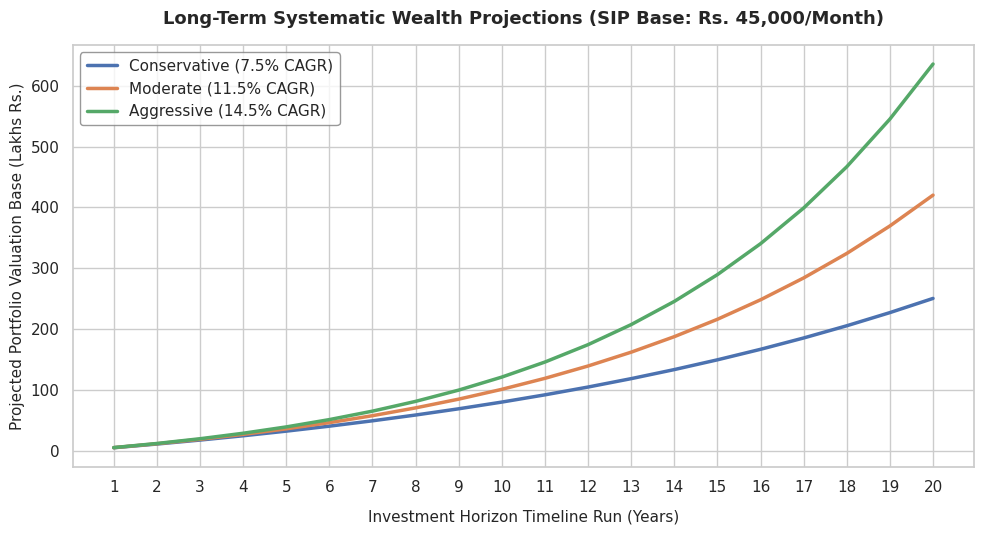

In [11]:
# =============================================================================
# CELL 11: WEALTH SIP PROJECTION ENGINE (BUSINESS ACTION & OUTCOME VISUALIZATION)
# =============================================================================

# Step 1: Establish long-term annualized CAGR targets per risk profile category
risk_adjusted_return_map = {
    "Conservative": 0.075,  # 7.5% expected growth profile
    "Moderate": 0.115,      # 11.5% expected growth profile
    "Aggressive": 0.145     # 14.5% expected growth profile
}

# Step 2: Implement a Future Value Compound Growth Function for Systematic Investment Plans (SIP)
def compute_future_sip_wealth(monthly_investment, horizon_years, annual_cagr):
    monthly_rate = annual_cagr / 12
    total_months = int(horizon_years * 12)
    if monthly_rate == 0:
        return monthly_investment * total_months
    # Standard financial future value formula for an ordinary annuity due
    accumulated_wealth = monthly_investment * (((1 + monthly_rate) ** total_months - 1) / monthly_rate) * (1 + monthly_rate)
    return accumulated_wealth

# Step 3: Run projections using the live client's actual investable monthly surplus
client_monthly_sip = float(live_onboarding_payload["monthly_surplus"].iloc[0])
client_investment_runway = int(live_onboarding_payload["investment_horizon_years"].iloc[0])
assigned_growth_rate = risk_adjusted_return_map[final_predicted_risk_profile]

calculated_terminal_wealth = compute_future_sip_wealth(client_monthly_sip, client_investment_runway, assigned_growth_rate)
total_principal_invested = client_monthly_sip * 12 * client_investment_runway
computed_wealth_gain = calculated_terminal_wealth - total_principal_invested

print("===========================================================================")
print(f"FINANCIAL OUTCOME FORECAST ({client_investment_runway}-YEAR PLANNING RUNWAY)")
print("===========================================================================")
print(f"Planned Monthly SIP Stream        : Rs. {client_monthly_sip:,.2f}")
print(f"Cumulative Base Outlay Capital     : Rs. {total_principal_invested:,.2f}")
print(f"Projected Portfolio Terminal Value: Rs. {calculated_terminal_wealth:,.2f}")
print(f"Net AI-Driven Estimated Growth Gain: Rs. {computed_wealth_gain:,.2f}")
print("===========================================================================")

# Step 4: Generate a 20-Year Long-Term Comparative Strategic Growth Projection Chart
projection_years_axis = np.arange(1, 21)
plt.figure(figsize=(10, 5.5))

for risk_label, performance_cagr in risk_adjusted_return_map.items():
    yearly_wealth_milestones = [
        compute_future_sip_wealth(client_monthly_sip, year, performance_cagr) for year in projection_years_axis
    ]
    plt.plot(projection_years_axis, np.array(yearly_wealth_milestones) / 100000, label=f"{risk_label} ({performance_cagr*100:.1f}% CAGR)", linewidth=2.5)

plt.title(f"Long-Term Systematic Wealth Projections (SIP Base: Rs. {client_monthly_sip:,.0f}/Month)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Investment Horizon Timeline Run (Years)", fontsize=11, labelpad=10)
plt.ylabel("Projected Portfolio Valuation Base (Lakhs Rs.)", fontsize=11)
plt.xticks(np.arange(1, 21, 1))
plt.legend(frameon=True, facecolor="white", edgecolor="gray")
plt.tight_layout()
plt.show()